# DiT-Base - Binary Classification - 20K Passport Dataset

**Goal:** Train DiT-Base (microsoft/dit-base) pre-trained on 42M document images for binary forgery detection on passports. Compare with ViT-Small (ImageNet) to evaluate if document-specific pre-training improves forgery detection.

## Dataset
- **20,000 images** = 10,000 Real + 10,000 Fake
- **~3,333 subjects per country** (ALB, GRC, LVA)
- Train: 16,000 | Val: 2,000 | Test: 2,000

## Architecture

| Setting | Value |
|---------|-------|
| **Model** | DiT-Base (768-dim, 86M params) |
| **Pre-training** | IIT-CDIP (42M document images) |
| **Loss** | Focal Loss (gamma=2.0) |
| **Training** | 3-stage gradual unfreezing |
| **Head** | MLP (LayerNorm → Linear → GELU → Dropout → Linear) |
| **TTA** | 4 augmented views |

## Setup

In [1]:
import os
import sys

project_root = "/Users/roy-siftt/final-project"
if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Working directory: {os.getcwd()}")

Working directory: /Users/roy-siftt/final-project


In [2]:
%pip install -q huggingface_hub


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from huggingface_hub import hf_hub_download
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Device
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

Using device: mps


## Load Data (20K Passport Dataset)

In [4]:
data_dir = "/Users/roy-siftt/final-project/notebooks/passport_forgery/production/data"
dataset_root = "/Users/roy-siftt/final-project/datasets/passport_20k"

train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")
print(f"\nTrain balance: Real={len(train_df[train_df['is_fake']==0])}, Fake={len(train_df[train_df['is_fake']==1])}")
print(f"Val balance:   Real={len(val_df[val_df['is_fake']==0])}, Fake={len(val_df[val_df['is_fake']==1])}")
print(f"Test balance:  Real={len(test_df[test_df['is_fake']==0])}, Fake={len(test_df[test_df['is_fake']==1])}")

Train: 16000 | Val: 2000 | Test: 2000
Total: 20000

Train balance: Real=8000, Fake=8000
Val balance:   Real=1000, Fake=1000
Test balance:  Real=1000, Fake=1000


## Focal Loss

In [5]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance and hard examples.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print("Focal Loss defined (gamma=2.0 focuses on hard examples)")

Focal Loss defined (gamma=2.0 focuses on hard examples)


## Lighter Augmentation Strategy

Preserve forgery artifacts, minimal blur/noise, NO CoarseDropout.

In [6]:
# LIGHTER augmentation - preserve forgery artifacts
train_transform = A.Compose([
    A.Resize(224, 224),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.08,
        rotate_limit=8,
        border_mode=0,
        p=0.5
    ),
    A.Perspective(
        scale=(0.02, 0.05),
        p=0.2
    ),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.1
    ),
    A.GaussNoise(
        std_range=(0.01, 0.03),
        p=0.1
    ),
    A.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02,
        p=0.3
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

# Test-Time Augmentation transforms
tta_transforms = [
    val_test_transform,
    A.Compose([
        A.Resize(224, 224),
        A.Affine(scale=(0.95, 0.95), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    A.Compose([
        A.Resize(224, 224),
        A.Affine(scale=(1.05, 1.05), p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
    A.Compose([
        A.Resize(224, 224),
        A.ColorJitter(brightness=0.1, contrast=0, saturation=0, hue=0, p=1.0),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]),
]

print("Augmentation strategy:")
print("  - LIGHTER transforms to preserve forgery artifacts")
print("  - NO CoarseDropout (can hide forgery regions)")
print("  - Minimal blur/noise (artifacts are in fine details)")
print("  - TTA: 4 augmented views for evaluation")

Augmentation strategy:
  - LIGHTER transforms to preserve forgery artifacts
  - NO CoarseDropout (can hide forgery regions)
  - Minimal blur/noise (artifacts are in fine details)
  - TTA: 4 augmented views for evaluation


## Dataset Class

In [7]:
class BinaryForgeryDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['image_path'])
        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        
        if self.transform is not None:
            transformed = self.transform(image=img_np)
            img = transformed['image']

        is_fake = int(row['is_fake'])
        return img, torch.tensor(is_fake, dtype=torch.long)

# Create datasets
train_dataset = BinaryForgeryDataset(train_df, dataset_root, train_transform)
val_dataset = BinaryForgeryDataset(val_df, dataset_root, val_test_transform)
test_dataset = BinaryForgeryDataset(test_df, dataset_root, val_test_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Batch size: 32")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Batch size: 32
Train batches: 500 | Val batches: 63 | Test batches: 63


## DiT-Base Model with MLP Head

DiT (Document Image Transformer) uses BEiT architecture pre-trained on IIT-CDIP (42M document images).
- 768-dim embeddings, 86M parameters
- MLP head: 768 → 384 → 2
- Gradual unfreezing via `dit.encoder.layer` and `dit.layernorm`

In [8]:
class DiTBinaryClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.1):
        super(DiTBinaryClassifier, self).__init__()
        
        # Use timm ViT-Base with layer scale (same architecture as DiT-Base)
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0, init_values=1e-5)
        self._load_dit_weights()
        num_features = 768
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(num_features),
            nn.Linear(num_features, num_features // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(num_features // 2, num_classes)
        )
        
        print(f"Model: DiT-Base (microsoft/dit-base) via timm")
        print(f"  - Pre-training: IIT-CDIP (42M document images)")
        print(f"  - Embedding dim: {num_features}")
        print(f"  - MLP head: {num_features} -> {num_features//2} -> {num_classes}")
        print(f"  - Dropout: {dropout}")
        print(f"  - Total params: {sum(p.numel() for p in self.parameters()):,}")
    
    def _load_dit_weights(self):
        weights_path = hf_hub_download(repo_id='microsoft/dit-base', filename='pytorch_model.bin')
        dit_state = torch.load(weights_path, map_location='cpu', weights_only=True)
        converted = self._convert_dit_to_timm(dit_state)
        self.backbone.load_state_dict(converted, strict=True)
        print(f"  - DiT weights loaded: {len(converted)} keys matched")
    
    @staticmethod
    def _convert_dit_to_timm(dit_state_dict):
        """Convert HuggingFace DiT/BEiT state dict to timm ViT format."""
        new_state = {}
        for key, value in dit_state_dict.items():
            k = key.replace('beit.', '') if key.startswith('beit.') else key
            if k in ('embeddings.mask_token',): continue
            if k.startswith('layernorm.'):
                new_state[k.replace('layernorm.', 'norm.')] = value; continue
            if k.startswith('classifier.') or k.startswith('lm_head.'): continue
            if k == 'embeddings.cls_token':
                new_state['cls_token'] = value; continue
            if k == 'embeddings.position_embeddings':
                new_state['pos_embed'] = value; continue
            if k.startswith('embeddings.patch_embeddings.projection.'):
                new_state[k.replace('embeddings.patch_embeddings.projection.', 'patch_embed.proj.')] = value; continue
            if k.startswith('encoder.layer.'):
                rest = k[len('encoder.layer.'):]
                layer_idx = rest.split('.')[0]
                layer_rest = rest[len(layer_idx) + 1:]
                prefix = f'blocks.{layer_idx}'
                if layer_rest == 'attention.attention.query.weight':
                    new_state[f'{prefix}.attn.q.weight'] = value; continue
                if layer_rest == 'attention.attention.key.weight':
                    new_state[f'{prefix}.attn.k.weight'] = value; continue
                if layer_rest == 'attention.attention.value.weight':
                    new_state[f'{prefix}.attn.v.weight'] = value; continue
                if layer_rest == 'attention.attention.query.bias':
                    new_state[f'{prefix}.attn.q.bias'] = value; continue
                if layer_rest == 'attention.attention.value.bias':
                    new_state[f'{prefix}.attn.v.bias'] = value; continue
                if layer_rest.startswith('attention.output.dense.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.attn.proj.{suffix}'] = value; continue
                if layer_rest.startswith('intermediate.dense.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.mlp.fc1.{suffix}'] = value; continue
                if layer_rest.startswith('output.dense.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.mlp.fc2.{suffix}'] = value; continue
                if layer_rest.startswith('layernorm_before.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.norm1.{suffix}'] = value; continue
                if layer_rest.startswith('layernorm_after.'):
                    suffix = layer_rest.split('.')[-1]
                    new_state[f'{prefix}.norm2.{suffix}'] = value; continue
                if layer_rest == 'lambda_1':
                    new_state[f'{prefix}.ls1.gamma'] = value; continue
                if layer_rest == 'lambda_2':
                    new_state[f'{prefix}.ls2.gamma'] = value; continue

        # Fuse Q, K, V weights and biases
        import torch
        fused_state = {}
        q_weight_keys = sorted([k for k in new_state if '.attn.q.weight' in k])
        for q_key in q_weight_keys:
            bp = q_key.replace('.attn.q.weight', '')
            q_w = new_state[f'{bp}.attn.q.weight']
            k_w = new_state[f'{bp}.attn.k.weight']
            v_w = new_state[f'{bp}.attn.v.weight']
            fused_state[f'{bp}.attn.qkv.weight'] = torch.cat([q_w, k_w, v_w], dim=0)
            q_b = new_state[f'{bp}.attn.q.bias']
            v_b = new_state[f'{bp}.attn.v.bias']
            k_b = torch.zeros_like(q_b)
            fused_state[f'{bp}.attn.qkv.bias'] = torch.cat([q_b, k_b, v_b], dim=0)

        skip = ('.attn.q.weight', '.attn.k.weight', '.attn.v.weight', '.attn.q.bias', '.attn.v.bias')
        for k, v in new_state.items():
            if not any(k.endswith(s) for s in skip):
                fused_state[k] = v
        return fused_state
        
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)
    
    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        print("Backbone FROZEN")
    
    def unfreeze_backbone(self):
        for param in self.parameters():
            param.requires_grad = True
        print("Backbone UNFROZEN")
    
    def unfreeze_last_n_blocks(self, n=4):
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        for block in self.backbone.blocks[-n:]:
            for param in block.parameters():
                param.requires_grad = True
        for param in self.backbone.norm.parameters():
            param.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"Last {n} transformer blocks UNFROZEN ({trainable:,}/{total:,} trainable)")

model = DiTBinaryClassifier(num_classes=2).to(device)

  - DiT weights loaded: 174 keys matched
Model: DiT-Base (microsoft/dit-base) via timm
  - Pre-training: IIT-CDIP (42M document images)
  - Embedding dim: 768
  - MLP head: 768 -> 384 -> 2
  - Dropout: 0.1
  - Total params: 86,114,690


## Training with 3-Stage Unfreezing + OneCycleLR

1. **Stage 1 (10 epochs):** Train only classifier head, lr=5e-4
2. **Stage 2 (15 epochs):** Unfreeze last 4 transformer blocks, lr=3e-5
3. **Stage 3 (25 epochs):** Full fine-tuning, lr=5e-6, patience=8

In [9]:
# Loss function
criterion = FocalLoss(alpha=1.0, gamma=2.0)

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'lr': []
}

# Best model tracking
best_val_acc = 0.0
best_model_state = None
best_epoch = 0

max_grad_norm = 1.0

def evaluate(loader, use_tta=False):
    model.eval()
    
    if not use_tta:
        total, correct = 0, 0
        loss_total = 0.0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss_total += loss.item()
                
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        return {
            'acc': correct / total,
            'loss': loss_total / len(loader),
            'preds': all_preds,
            'labels': all_labels
        }
    else:
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for imgs, labels in loader:
                batch_probs = []
                imgs_np = imgs.numpy().transpose(0, 2, 3, 1)
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                imgs_np = (imgs_np * std + mean) * 255
                imgs_np = imgs_np.astype(np.uint8)
                
                for tta_transform in tta_transforms:
                    tta_imgs = []
                    for img in imgs_np:
                        transformed = tta_transform(image=img)
                        tta_imgs.append(transformed['image'])
                    tta_batch = torch.stack(tta_imgs).to(device)
                    outputs = model(tta_batch)
                    probs = F.softmax(outputs, dim=1)
                    batch_probs.append(probs.cpu())
                
                avg_probs = torch.stack(batch_probs).mean(dim=0)
                all_probs.append(avg_probs)
                all_labels.extend(labels.numpy())
        
        all_probs = torch.cat(all_probs, dim=0)
        all_preds = all_probs.argmax(dim=1).numpy()
        all_labels = np.array(all_labels)
        
        correct = (all_preds == all_labels).sum()
        total = len(all_labels)
        
        return {
            'acc': correct / total,
            'loss': 0.0,
            'preds': all_preds.tolist(),
            'labels': all_labels.tolist()
        }

def train_one_epoch(train_loader, optimizer, scheduler, epoch_desc):
    model.train()
    total_loss = 0.0
    
    pbar = tqdm(train_loader, desc=epoch_desc)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})
    
    return total_loss / len(train_loader)

print("Training functions defined")
print(f"  - Focal Loss (gamma=2.0)")
print(f"  - Gradient clipping (max_norm=1.0)")
print(f"  - TTA evaluation available")

Training functions defined
  - Focal Loss (gamma=2.0)
  - Gradient clipping (max_norm=1.0)
  - TTA evaluation available


In [10]:
# ============================================
# STAGE 1: Train Classifier Head Only
# ============================================
print("\n" + "="*70)
print("STAGE 1: Training Classifier Head (10 epochs, lr=5e-4)")
print("="*70)

model.freeze_backbone()

stage1_epochs = 10
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer, 
    max_lr=5e-4,
    epochs=stage1_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

for epoch in range(stage1_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S1 Epoch {epoch+1}/{stage1_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc:
        best_val_acc = val_metrics['acc']
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best: {best_val_acc:.4f}")

stage1_end = len(history['train_loss'])
print(f"\nStage 1 complete. Best val acc: {best_val_acc:.4f}")


STAGE 1: Training Classifier Head (10 epochs, lr=5e-4)
Backbone FROZEN


S1 Epoch 1/10: 100%|██████████| 500/500 [04:55<00:00,  1.69it/s, loss=0.1752, lr=5.00e-04]


  Train Acc: 0.5000 | Val Acc: 0.5000 | Val Loss: 0.1766
  -> New best: 0.5000


S1 Epoch 2/10: 100%|██████████| 500/500 [04:54<00:00,  1.70it/s, loss=0.1765, lr=4.85e-04]


  Train Acc: 0.4998 | Val Acc: 0.5000 | Val Loss: 0.1733


...

  Train Acc: 0.5002 | Val Acc: 0.5000 | Val Loss: 0.1733


S1 Epoch 9/10: 100%|██████████| 500/500 [04:49<00:00,  1.72it/s, loss=0.1734, lr=1.50e-05]


  Train Acc: 0.5000 | Val Acc: 0.5000 | Val Loss: 0.1733


S1 Epoch 10/10: 100%|██████████| 500/500 [04:52<00:00,  1.71it/s, loss=0.1740, lr=2.06e-09]


  Train Acc: 0.5000 | Val Acc: 0.5000 | Val Loss: 0.1733

Stage 1 complete. Best val acc: 0.5000


In [11]:
# ============================================
# STAGE 2: Unfreeze Last 4 Transformer Blocks
# ============================================
print("\n" + "="*70)
print("STAGE 2: Unfreezing Last 4 Blocks (15 epochs, lr=3e-5)")
print("="*70)

model.unfreeze_last_n_blocks(n=4)

stage2_epochs = 15
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-5, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer,
    max_lr=3e-5,
    epochs=stage2_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy='cos'
)

for epoch in range(stage2_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S2 Epoch {epoch+1}/{stage2_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    total_epoch = stage1_end + epoch + 1
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc:
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  -> New best: {best_val_acc:.4f}")

stage2_end = len(history['train_loss'])
print(f"\nStage 2 complete. Best val acc: {best_val_acc:.4f}")


STAGE 2: Unfreezing Last 4 Blocks (15 epochs, lr=3e-5)
Last 4 transformer blocks UNFROZEN (28,656,770/86,114,690 trainable)


S2 Epoch 1/15: 100%|██████████| 500/500 [06:01<00:00,  1.38it/s, loss=0.1702, lr=2.28e-05]


  Train Acc: 0.5000 | Val Acc: 0.5000 | Val Loss: 0.1735


S2 Epoch 2/15: 100%|██████████| 500/500 [05:58<00:00,  1.39it/s, loss=0.1526, lr=2.99e-05]


  Train Acc: 0.6101 | Val Acc: 0.6155 | Val Loss: 0.1589
  -> New best: 0.6155


...

  Train Acc: 0.7300 | Val Acc: 0.7745 | Val Loss: 0.1013


S2 Epoch 14/15: 100%|██████████| 500/500 [06:03<00:00,  1.37it/s, loss=0.1162, lr=4.03e-07]


  Train Acc: 0.7326 | Val Acc: 0.7725 | Val Loss: 0.1013


S2 Epoch 15/15: 100%|██████████| 500/500 [06:12<00:00,  1.34it/s, loss=0.1538, lr=1.22e-10]


  Train Acc: 0.7317 | Val Acc: 0.7705 | Val Loss: 0.1013

Stage 2 complete. Best val acc: 0.7745


In [12]:
# ============================================
# STAGE 3: Full Fine-Tuning
# ============================================
print("\n" + "="*70)
print("STAGE 3: Full Fine-Tuning (25 epochs, lr=5e-6, patience=8)")
print("="*70)

model.unfreeze_backbone()

stage3_epochs = 25
optimizer = AdamW(model.parameters(), lr=5e-6, weight_decay=0.01)
scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-6,
    epochs=stage3_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.05,
    anneal_strategy='cos'
)

patience = 8
patience_counter = 0

for epoch in range(stage3_epochs):
    train_loss = train_one_epoch(train_loader, optimizer, scheduler, f"S3 Epoch {epoch+1}/{stage3_epochs}")
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    total_epoch = stage2_end + epoch + 1
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    print(f"  Train Acc: {train_metrics['acc']:.4f} | Val Acc: {val_metrics['acc']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    
    if val_metrics['acc'] > best_val_acc + 0.002:
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> New best: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {total_epoch}")
            break

print(f"\nStage 3 complete. Best val acc: {best_val_acc:.4f} at epoch {best_epoch}")


STAGE 3: Full Fine-Tuning (25 epochs, lr=5e-6, patience=8)
Backbone UNFROZEN


S3 Epoch 1/25: 100%|██████████| 500/500 [08:51<00:00,  1.06s/it, loss=0.1303, lr=4.55e-06]


  Train Acc: 0.7279 | Val Acc: 0.7745 | Val Loss: 0.1007


S3 Epoch 2/25: 100%|██████████| 500/500 [08:54<00:00,  1.07s/it, loss=0.1006, lr=4.99e-06]


  Train Acc: 0.7335 | Val Acc: 0.7770 | Val Loss: 0.1028
  -> New best: 0.7770


...

  Train Acc: 0.7936 | Val Acc: 0.8105 | Val Loss: 0.0908


S3 Epoch 24/25: 100%|██████████| 500/500 [09:15<00:00,  1.11s/it, loss=0.0880, lr=2.18e-08]


  Train Acc: 0.7897 | Val Acc: 0.8135 | Val Loss: 0.0908


S3 Epoch 25/25: 100%|██████████| 500/500 [09:29<00:00,  1.14s/it, loss=0.1159, lr=2.01e-11]


  Train Acc: 0.7949 | Val Acc: 0.8150 | Val Loss: 0.0908

Stage 3 complete. Best val acc: 0.8140 at epoch 46


In [13]:
# Load best model
print("\n" + "="*70)
print("Loading Best Model")
print("="*70)

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model from epoch {best_epoch}")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
else:
    print("Warning: No best model state saved")


Loading Best Model
Loaded best model from epoch 46
Best validation accuracy: 0.8140


## Final Evaluation

In [14]:
# Standard evaluation
print("\n" + "="*70)
print("FINAL TEST EVALUATION")
print("="*70)

test_metrics = evaluate(test_loader, use_tta=False)
print(f"\nTest Accuracy (standard): {test_metrics['acc']:.4f}")

# TTA evaluation
print("\nRunning Test-Time Augmentation (4 views)...")
test_metrics_tta = evaluate(test_loader, use_tta=True)
print(f"Test Accuracy (with TTA): {test_metrics_tta['acc']:.4f}")

print(f"\n{'='*50}")
print("RESULTS")
print(f"{'='*50}")
print(f"Test Accuracy (standard):  {test_metrics['acc']*100:.2f}%")
print(f"Test Accuracy (with TTA):  {test_metrics_tta['acc']*100:.2f}%")
print(f"{'='*50}")


FINAL TEST EVALUATION

Test Accuracy (standard): 0.8300

Running Test-Time Augmentation (4 views)...
Test Accuracy (with TTA): 0.8245

RESULTS
Test Accuracy (standard):  83.00%
Test Accuracy (with TTA):  82.45%


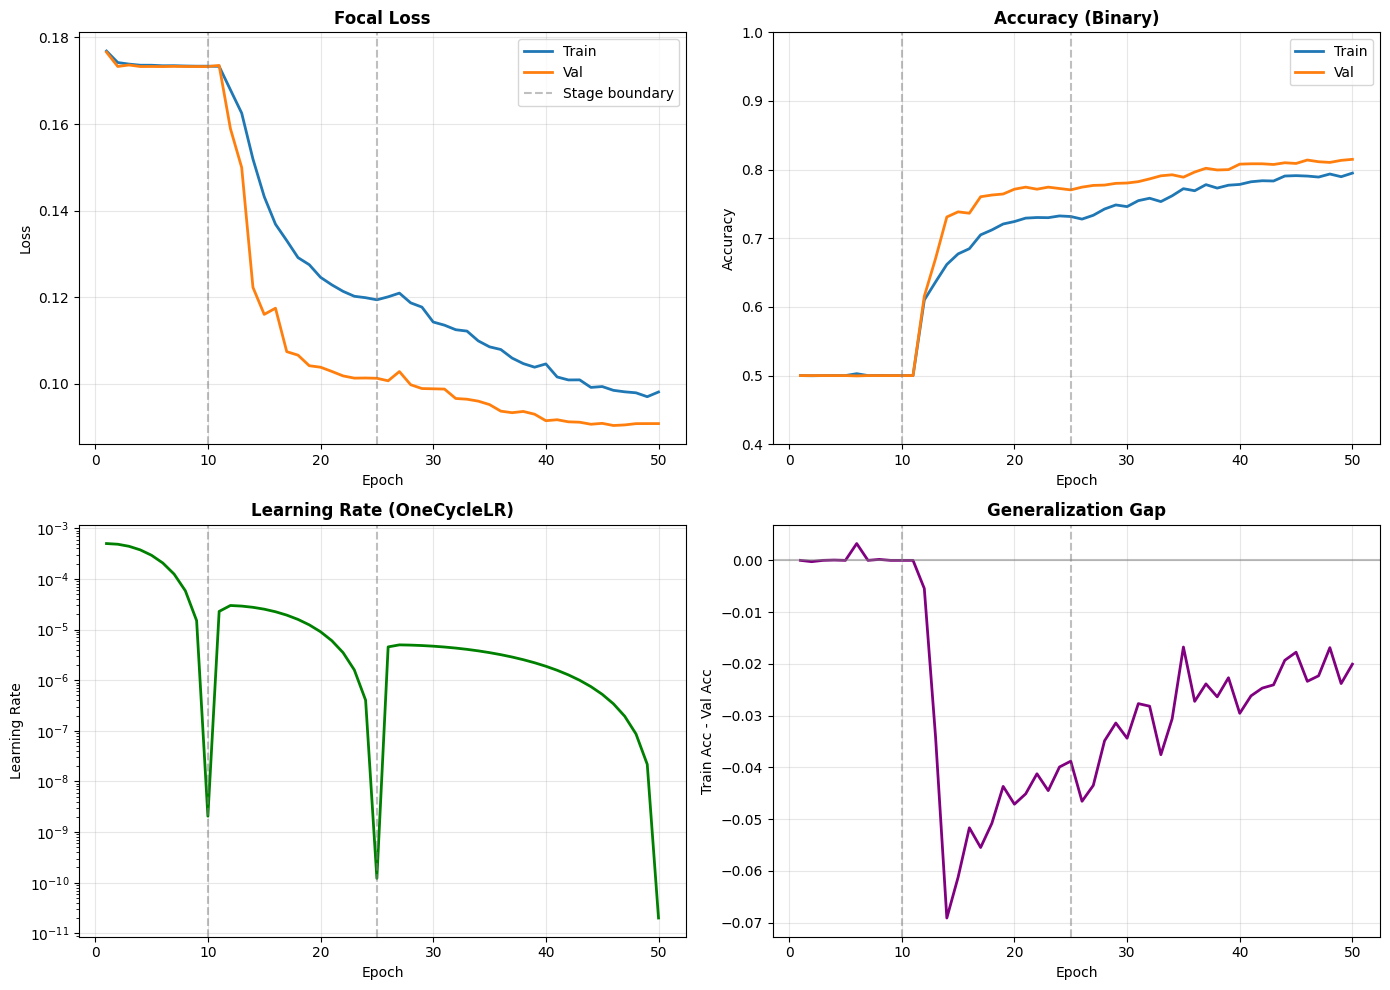

In [15]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs, history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], label='Val', linewidth=2)
axes[0, 0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5, label='Stage boundary')
axes[0, 0].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Focal Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, history['train_acc'], label='Train', linewidth=2)
axes[0, 1].plot(epochs, history['val_acc'], label='Val', linewidth=2)
axes[0, 1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy (Binary)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.4, 1.0])

# Learning rate
axes[1, 0].plot(epochs, history['lr'], linewidth=2, color='green')
axes[1, 0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate (OneCycleLR)', fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Generalization gap
gen_gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(epochs, gen_gap, linewidth=2, color='purple')
axes[1, 1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1, 1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=stage2_end, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Train Acc - Val Acc')
axes[1, 1].set_title('Generalization Gap', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/passport_forgery/production/training_curves_dit_binary_20k.png', dpi=150)
plt.show()


CONFUSION MATRIX


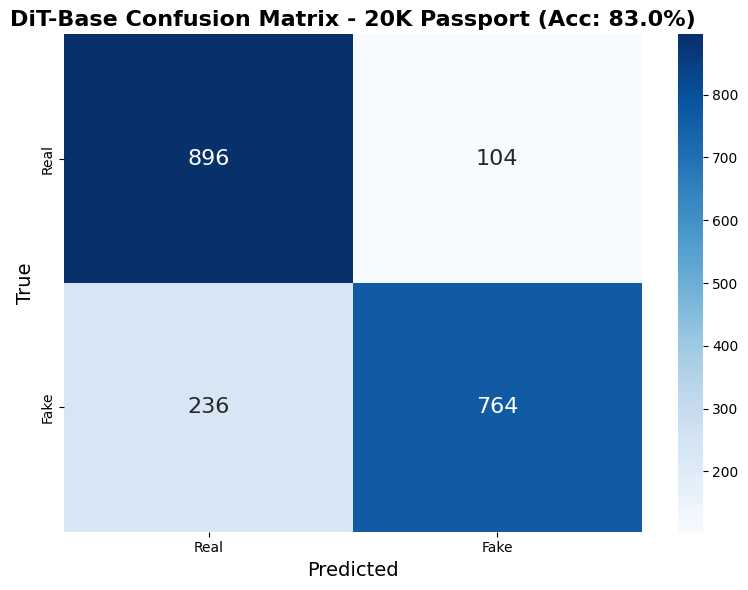


Classification Report:
              precision    recall  f1-score   support

        Real       0.79      0.90      0.84      1000
        Fake       0.88      0.76      0.82      1000

    accuracy                           0.83      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.84      0.83      0.83      2000



In [16]:
# Confusion Matrix
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
labels = ['Real', 'Fake']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=14)
ax.set_ylabel('True', fontsize=14)
ax.set_title(f'DiT-Base Confusion Matrix - 20K Passport (Acc: {test_metrics["acc"]*100:.1f}%)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/passport_forgery/production/confusion_matrix_dit_binary_20k.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(test_metrics['labels'], test_metrics['preds'], target_names=labels))

## Save Model + History

In [17]:
import pickle
import shutil

notebook_dir = "/Users/roy-siftt/final-project/notebooks/passport_forgery/production"
model_path = os.path.join(notebook_dir, "dit_binary_20k.pth")

# Check disk space
disk = shutil.disk_usage(notebook_dir)
free_gb = disk.free / (1024**3)
print(f"Disk space available: {free_gb:.1f} GB")

if free_gb < 0.5:
    print("WARNING: Low disk space! Saving to /tmp/ instead")
    model_path = "/tmp/dit_binary_20k.pth"

# Save best model (move tensors to CPU first)
try:
    if best_model_state is not None:
        cpu_state = {k: v.cpu() for k, v in best_model_state.items()}
        torch.save(cpu_state, model_path)
        print(f"Model saved to: {model_path}")
        print(f"  Best epoch: {best_epoch}")
        print(f"  Best val acc: {best_val_acc:.4f}")
        print(f"  Test acc: {test_metrics['acc']:.4f}")
        print(f"  Test acc (TTA): {test_metrics_tta['acc']:.4f}")
    else:
        cpu_state = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save(cpu_state, model_path)
        print(f"Model saved to: {model_path}")
except Exception as e:
    print(f"Save failed: {e}")
    fallback = "/tmp/dit_binary_20k.pth"
    cpu_state = {k: v.cpu() for k, v in (best_model_state or model.state_dict()).items()}
    torch.save(cpu_state, fallback)
    print(f"Saved to fallback: {fallback}")

# Save training history
history_path = os.path.join(notebook_dir, "training_history_dit_binary_20k.pkl")
with open(history_path, 'wb') as f:
    pickle.dump(history, f)
print(f"Training history saved to: {history_path}")

# Verify file size
if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Model file size: {size_mb:.1f} MB")

Disk space available: 10.0 GB
Model saved to: /Users/roy-siftt/final-project/notebooks/passport_forgery/production/dit_binary_20k.pth
  Best epoch: 46
  Best val acc: 0.8140
  Test acc: 0.8300
  Test acc (TTA): 0.8245
Training history saved to: /Users/roy-siftt/final-project/notebooks/passport_forgery/production/training_history_dit_binary_20k.pkl
Model file size: 328.6 MB


## Out-of-Dataset Evaluation (test_samples.json)

In [18]:
import json

# Auto-reload if needed (for running this cell in a fresh kernel)
if 'tta_transforms' not in dir():
    print("Reloading transforms...")
    tta_transforms = [
        A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.Affine(scale=(0.95, 0.95), p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.Affine(scale=(1.05, 1.05), p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(224, 224),
            A.ColorJitter(brightness=0.1, contrast=0, saturation=0, hue=0, p=1.0),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]),
    ]

def predict_single(image_path, model, device):
    """Predict on a single image with TTA"""
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    
    model.eval()
    all_probs = []
    
    with torch.no_grad():
        for transform in tta_transforms:
            transformed = transform(image=img_np)
            img_tensor = transformed['image'].unsqueeze(0).to(device)
            outputs = model(img_tensor)
            probs = F.softmax(outputs, dim=1)
            all_probs.append(probs.cpu())
    
    avg_probs = torch.stack(all_probs).mean(dim=0)
    pred = avg_probs.argmax(dim=1).item()
    confidence = avg_probs[0][pred].item()
    
    return pred, confidence

# Load test samples
samples_path = os.path.join(project_root, "notebooks/passport_forgery/experiments/test_samples.json")
with open(samples_path) as f:
    samples = json.load(f)

print(f"\n{'='*70}")
print(f"OUT-OF-DATASET EVALUATION ({len(samples)} unseen samples)")
print(f"{'='*70}")

true_labels, pred_labels, details = [], [], []
skipped = 0

for s in tqdm(samples, desc="Evaluating"):
    img_path = os.path.join(project_root, s['path'])
    if not os.path.exists(img_path):
        skipped += 1
        continue

    pred_idx, confidence = predict_single(img_path, model, device)
    true_idx = s['is_fake']
    pred_label = "Fake" if pred_idx == 1 else "Real"
    true_label = s['expected_binary']

    true_labels.append(true_idx)
    pred_labels.append(pred_idx)
    details.append({
        'path': s['path'],
        'country': s['country'],
        'fraud_type': s['fraud_type'],
        'true': true_label,
        'pred': pred_label,
        'confidence': confidence,
        'correct': pred_label == true_label
    })

if skipped:
    print(f"Skipped {skipped} (file not found)")

# Results
correct = sum(d['correct'] for d in details)
total = len(details)
ood_accuracy = correct / total

print(f"\nOverall Accuracy: {ood_accuracy:.4f} ({correct}/{total})")

# Per class
print(f"\nPer Class:")
for label in ['Real', 'Fake']:
    subset = [d for d in details if d['true'] == label]
    acc = sum(d['correct'] for d in subset) / len(subset)
    avg_conf = sum(d['confidence'] for d in subset) / len(subset)
    print(f"  {label:5s}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)}) avg conf: {avg_conf:.4f}")

# Per fraud type
print(f"\nPer Fraud Type:")
fraud_types = sorted(set(d['fraud_type'] for d in details))
for ftype in fraud_types:
    subset = [d for d in details if d['fraud_type'] == ftype]
    acc = sum(d['correct'] for d in subset) / len(subset)
    print(f"  {ftype:20s}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)})")

# Per country
print(f"\nPer Country:")
for country in ['ALB', 'GRC', 'LVA']:
    subset = [d for d in details if d['country'] == country]
    if len(subset) > 0:
        acc = sum(d['correct'] for d in subset) / len(subset)
        print(f"  {country}: {acc:.4f} ({sum(d['correct'] for d in subset)}/{len(subset)})")
    else:
        print(f"  {country}: no samples")

# Classification report
print(f"\n{'='*60}")
print(classification_report(true_labels, pred_labels, target_names=['Real', 'Fake']))


OUT-OF-DATASET EVALUATION (2997 unseen samples)


Evaluating: 100%|██████████| 2997/2997 [05:28<00:00,  9.12it/s]


Overall Accuracy: 0.7915 (2372/2997)

Per Class:
  Real : 0.8969 (896/999) avg conf: 0.6917
  Fake : 0.7387 (1476/1998) avg conf: 0.7403

Per Fraud Type:
  face_morphing       : 0.5526 (552/999)
  face_replacement    : 0.9249 (924/999)
  real                : 0.8969 (896/999)

Per Country:
  ALB: 0.9980 (997/999)
  GRC: 0.7047 (704/999)
  LVA: 0.6717 (671/999)

              precision    recall  f1-score   support

        Real       0.63      0.90      0.74       999
        Fake       0.93      0.74      0.83      1998

    accuracy                           0.79      2997
   macro avg       0.78      0.82      0.78      2997
weighted avg       0.83      0.79      0.80      2997



In [19]:
# Final Summary
print("\n" + "="*70)
print("FINAL SUMMARY - DiT-Base Binary Classifier - 20K Passport Dataset")
print("="*70)
print(f"\nModel: DiT-Base (microsoft/dit-base, 86M params)")
print(f"Pre-training: IIT-CDIP (42M document images)")
print(f"Dataset: 20,000 passport images (16K train / 2K val / 2K test)")
print(f"Countries: ALB, GRC, LVA")
print(f"Training: 3-stage (head lr=5e-4 -> last 4 blocks lr=3e-5 -> full lr=5e-6), {len(history['train_loss'])} epochs")
print(f"Loss: Focal Loss (gamma=2.0)")
print(f"Batch size: 32")
print(f"\nResults:")
print(f"  Best Val Accuracy:        {best_val_acc:.4f}")
print(f"  Test Accuracy (standard): {test_metrics['acc']:.4f}")
print(f"  Test Accuracy (TTA):      {test_metrics_tta['acc']:.4f}")
print(f"  Out-of-Dataset Accuracy:  {ood_accuracy:.4f}")
print(f"\nModel saved to: notebooks/passport_forgery/production/dit_binary_20k.pth")
print(f"History saved to: notebooks/passport_forgery/production/training_history_dit_binary_20k.pkl")


FINAL SUMMARY - DiT-Base Binary Classifier - 20K Passport Dataset

Model: DiT-Base (microsoft/dit-base, 86M params)
Pre-training: IIT-CDIP (42M document images)
Dataset: 20,000 passport images (16K train / 2K val / 2K test)
Countries: ALB, GRC, LVA
Training: 3-stage (head lr=5e-4 -> last 4 blocks lr=3e-5 -> full lr=5e-6), 50 epochs
Loss: Focal Loss (gamma=2.0)
Batch size: 32

Results:
  Best Val Accuracy:        0.8140
  Test Accuracy (standard): 0.8300
  Test Accuracy (TTA):      0.8245
  Out-of-Dataset Accuracy:  0.7915

Model saved to: notebooks/passport_forgery/production/dit_binary_20k.pth
History saved to: notebooks/passport_forgery/production/training_history_dit_binary_20k.pkl
